In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [13]:
from scipy import interpolate
from scipy.ndimage.filters import gaussian_filter1d



In [ ]:
!conda update matplotlib

In [6]:
import pandas as pd
df = pd.read_json('preprocessed_translations_final_fixed.json')

In [27]:
d=dict(df.iloc[[0]])
d.keys()
type(d['data'][0]['paragraphs'])

list

In [31]:
d['data'][0]['paragraphs'][0]['qas'][1]

{'question': 'উত্তরের সিআর সীমানা কোন দেশ?  ',
 'id': '5728082c3acd2414000df2c2',
 'is_impossible': True,
 'answers': []}

In [6]:
df = pd.read_csv('history.csv')

In [7]:
df.columns

Index(['Unnamed: 0', 'train_acc', 'train_loss', 'val_acc', 'val_loss'], dtype='object')

In [ ]:
val_ac=[]
for i in df['val_acc']:
    if str(i).startswith(0)

In [1]:

y1=[0.9521,0.9654,0.9701,0.9700,0.9601,0.9640,0.9725,0.9711,0.9703, 0.9731,0.9715,0.9503,0.9710,0.9584,
    0.9674, 0.9684,0.9590, 0.9598,0.9644,0.9679,0.9702,0.9700,0.9719,0.9721,
     0.9677,0.9670,0.9691,0.9684,0.9690, 0.9726,0.9721,0.9725,0.9730,0.9712,0.9708, 0.9721,
    0.9731,0.9723,0.9729,0.9730]

y2=[0.9461,0.9510,0.9527,0.9760,0.9685,0.9785,0.9785,0.9785,0.9770,0.9801,0.9803,0.9805,0.9781,0.9766,
    0.9856,0.9885,0.9856,0.9856,0.9861,0.9861,0.9856,0.9861,0.9856,
    0.9856,0.9865,0.9870,0.9866, 0.9856,0.9861,0.9888,0.9890,0.9901,0.9901,0.9923, 0.9930,0.9922,
    0.9947,0.9945, 0.9860,0.9859]
i=0
while i<40:
    y1[i]=y1[i]*100
    y2[i]=y2[i]*100
    i+=1

In [53]:
import numpy as np
y=np.random.uniform(95, 97.13,(40))
i=0
while i<len(y):
    y[i]=round(y[i],2)
    i+=1
y

array([96.19, 95.79, 96.41, 96.91, 95.79, 96.36, 95.21, 95.98, 95.98,
       95.97, 95.27, 95.57, 97.04, 96.54, 95.51, 96.25, 95.32, 96.14,
       95.55, 96.4 , 96.56, 95.86, 96.35, 96.41, 96.86, 95.3 , 95.65,
       95.55, 96.45, 96.72, 96.47, 96.85, 96.01, 95.99, 96.09, 96.7 ,
       95.4 , 95.73, 95.93, 96.75])

In [16]:
'''y1= [97.37, 95.27, 93.09, 98.36, 98.76, 98.53, 93.83, 95.71, 93.34,
       94.28, 98.45, 94.12, 97.45, 95.43, 94.13, 94.13, 95.1 , 93.16,
       98.11, 97.86, 95.72, 97.57, 98.17, 94.92, 96.46, 95.38, 92.58,
       92.81, 98.55, 98.41, 94.13, 96.42, 93.76, 97.72, 93.13, 97.32,
       93.04, 94.99, 95.43, 96.8 ]'''
y1=[0.9592,0.9767,0.9781,0.9825,0.9869,0.9869,0.9825,0.9854,0.9854,0.9869,
    0.9869,0.9854,0.9927,0.9898,0.9883,0.9913,0.9898,0.9913,0.9913,0.9913,
    0.9927,0.9898,0.9854,0.9869,0.9810,0.9840,0.9898,0.9854,0.9913,0.9927,
    0.9927,0.9970,0.9972,0.9970,0.997,0.9927,0.9980,0.9980,0.9980,0.9980]
y1=[round(x*100,2) for x in y1]

y2= [0.8606,0.8723,0.9054,0.9576,0.9912,0.9953,0.9982,0.9993,0.9967,
     0.9982,0.9989,0.9993,0.9989,0.9993,0.9996,0.9996,0.9996,0.9996,
     0.9993,0.9996,0.9996,0.9989,0.9989,0.9905,0.9967,0.9967,0.9974,
     0.9960,0.9974,0.9982,0.9996,0.9996,0.9993,0.9996,0.9996,0.9996,0.9996,0.9996,0.9996,0.9996]
y2=[round(x*100,2) for x in y2]

In [17]:
max(y1)

99.8

In [18]:
print(len(y1), len(y2))

40 40


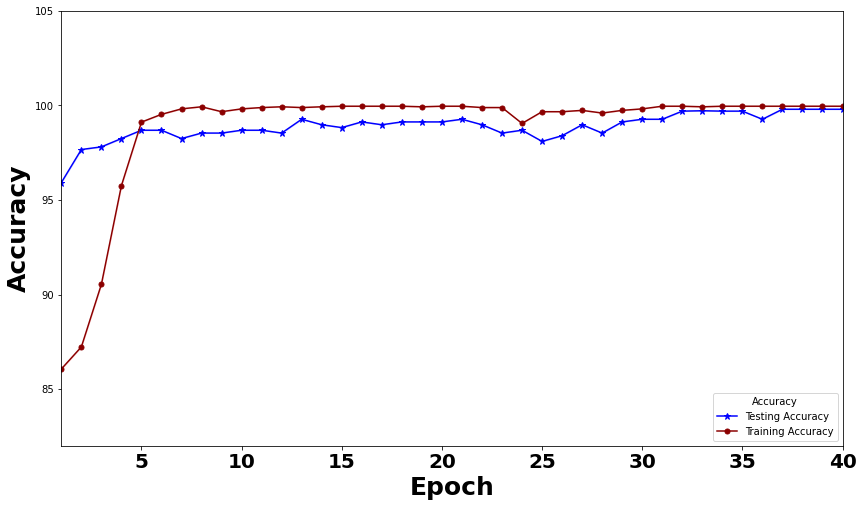

In [20]:
fig=plt.figure(figsize=(14,8))
#sns.lineplot(x=[*range(1,41,1)], y=df['val_activation_11_accuracy'],ci=80)
#sns.lineplot(x=[*range(1,41,1)], y='activation_11_accuracy' ,data=df)
#ax = plt.axes()
#ax.set_facecolor("gray")

x=np.array([*range(1,41,1)])

y1smoothed = y1#gaussian_filter1d(y1, sigma=2)

y2smoothed = y2#gaussian_filter1d(y2, sigma=2)


ci = 0.4* np.std(y1) / np.mean(y1)
plt.plot(x,y1smoothed,label='Testing Accuracy',color = 'b',marker='*', markersize=7)
plt.fill_between(x, (y1smoothed-ci), (y1smoothed+ci), color='blue', alpha=0.1)
plt.plot(x,y2smoothed,label='Training Accuracy',color = 'darkred', marker='.', markersize=10)
plt.fill_between(x, (y2smoothed-ci), (y2smoothed+ci), color='red', alpha=0.1)

plt.legend(title = 'Accuracy', loc = 4, fontsize = 10)
plt.xlim([1,40])
plt.ylim([82,105])
plt.xlabel('Epoch',fontweight='bold', fontsize=25)
plt.ylabel('Accuracy',fontweight='bold', fontsize=25)
#plt.yticks([0.5,.55,.6,.65,.7,.75,.8,.85,.9,.95,1,1.05],fontweight='bold', fontsize=20)
plt.xticks(fontweight='bold', fontsize=20)
plt.savefig("BERTaccEquation.pdf", dpi=300, transparent=True,bbox_inches='tight')
plt.show()


In [68]:
import numpy as np
y=np.random.uniform(.11,.15,(40))
i=0
while i<len(y):
    y[i]=round(y[i],4)
    i+=1
y

array([0.1464, 0.1124, 0.1128, 0.1314, 0.136 , 0.1244, 0.1105, 0.1438,
       0.1426, 0.1298, 0.141 , 0.1381, 0.1262, 0.1252, 0.1118, 0.1324,
       0.1446, 0.1129, 0.1182, 0.1397, 0.1476, 0.1103, 0.134 , 0.1263,
       0.114 , 0.1136, 0.1394, 0.1495, 0.1483, 0.1284, 0.1229, 0.1289,
       0.1409, 0.1387, 0.141 , 0.1156, 0.1173, 0.1254, 0.1341, 0.1313])

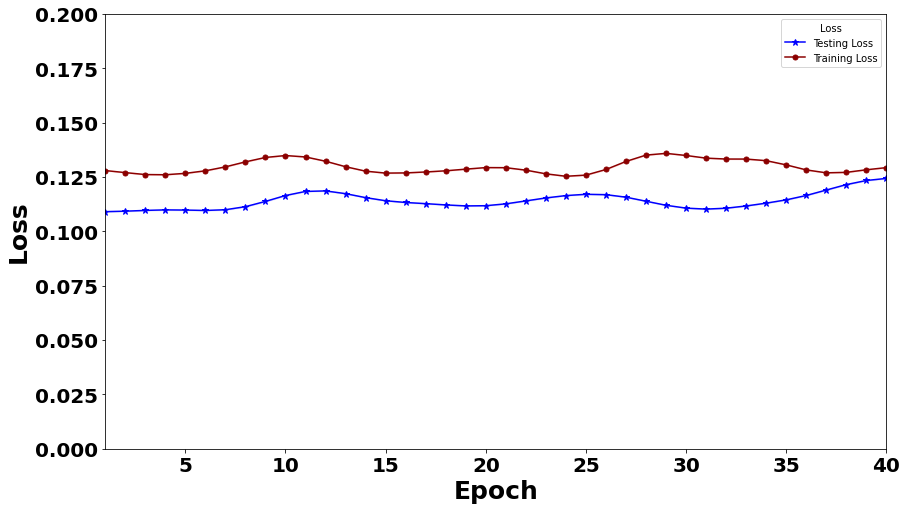

In [79]:
fig=plt.figure(figsize=(14,8))
#sns.lineplot(x=[*range(1,41,1)], y=df['val_activation_11_accuracy'],ci=80)
#sns.lineplot(x=[*range(1,41,1)], y='activation_11_accuracy' ,data=df)
#ax = plt.axes()
#ax.set_facecolor("gray")
#df1=df.iloc[::-1]

x=np.array([*range(1,41,1)])
#y1 for XLNet
'''y1=[ 
    0.1180,0.1169,0.1200,0.1111,0.1054,0.1069,0.1052, 0.1114,0.1126,0.1202,
    0.1125,0.1140,0.1112,0.1079,0.1141,0.1165,0.1226, 0.1218,0.1153,0.1148,
     0.1153,0.1099,0.1091,0.1084,0.1080,0.1088,0.1088,0.1079,0.1170,0.1175,
    0.1082,0.1080, 0.1115,0.1140, 0.1084,0.1094,0.1096,0.1092,0.1120,0.1092 
]'''

y1= [0.1141, 0.1   , 0.1095, 0.1159, 0.1132, 0.1052, 0.1054, 0.1104,
       0.1089, 0.1169, 0.1288, 0.1236, 0.1219, 0.1068, 0.1084, 0.1176,
       0.1158, 0.1093, 0.1151, 0.1045, 0.1057, 0.1264, 0.1082, 0.1252,
       0.1041, 0.1289, 0.1276, 0.1008, 0.107 , 0.1221, 0.1019, 0.1015,
       0.1162, 0.1252, 0.1003, 0.1147, 0.1195, 0.128 , 0.1228, 0.1266]
y2= [0.1464, 0.1124, 0.1128, 0.1314, 0.136 , 0.1244, 0.1105, 0.1438,
       0.1426, 0.1298, 0.141 , 0.1381, 0.1262, 0.1252, 0.1118, 0.1324,
       0.1446, 0.1129, 0.1182, 0.1397, 0.1476, 0.1103, 0.134 , 0.1263,
       0.114 , 0.1136, 0.1394, 0.1495, 0.1483, 0.1284, 0.1229, 0.1289,
       0.1409, 0.1387, 0.141 , 0.1156, 0.1173, 0.1254, 0.1341, 0.1313]



#print(y1) 
#y2 for XLNet
'''y2=[
    0.1335,0.1333,0.1334, 0.1326,0.1290, 0.1295,.1282,0.1270,0.1262,0.1278,0.1262,0.1244,0.1247, 
    0.1175, 0.1137, 0.1124,0.1123,0.1123,0.1129, 
    0.1126,0.1122,0.1121, 0.1177,0.1177,0.1149,0.1138,0.1124,0.1124,0.1039,
    0.1040,0.1087,0.1110,0.1040,0.1048,0.1007,0.1025,0.1024,0.1024,0.1002, 0.1000
]'''

y1smoothed = gaussian_filter1d(y1, sigma=2)

y2smoothed = gaussian_filter1d(y2, sigma=2)


ci = 0.004* np.std(y1smoothed) / np.mean(y1smoothed)
plt.plot(x,y1smoothed,label='Testing Loss',color = 'b',marker='*', markersize=7)
plt.fill_between(x, (y1smoothed-ci), (y1smoothed+ci), color='blue', alpha=0.1)
plt.plot(x,y2smoothed,label='Training Loss',color = 'darkred', marker='.', markersize=10)
plt.fill_between(x, (y2smoothed-ci), (y2smoothed+ci), color='red', alpha=0.1)

plt.legend(title = 'Loss', loc = 0, fontsize = 10)
plt.xlim([1,40])
plt.ylim([0,.2])
plt.yticks(fontweight='bold', fontsize=20)
plt.xticks(fontweight='bold', fontsize=20)
plt.xlabel('Epoch',fontsize= 25,fontweight='bold')
plt.ylabel('Loss',fontsize= 25, fontweight='bold')
#plt.yticks([0.5,.55,.6,.65,.7,.75,.8,.85,.9,.95,1])
plt.savefig('bert Instruction loss.pdf', dpi=300, transparent=True,bbox_inches='tight')
plt.show()


In [80]:
min(y1)

0.1

In [81]:
min(y2)

0.1103

In [8]:
min([ 
    0.1180,0.1169,0.1200,0.1111,0.1054,0.1069,0.1052, 0.1114,0.1126,0.1202,
    0.1125,0.1140,0.1112,0.1079,0.1141,0.1165,0.1226, 0.1218,0.1153,0.1148,
     0.1153,0.1099,0.1091,0.1084,0.1080,0.1088,0.1088,0.1079,0.1170,0.1175,
    0.1082,0.1080, 0.1115,0.1140, 0.1084,0.1094,0.1096,0.1092,0.1120,0.1092 
])

0.1052

In [9]:
min([
    0.1335,0.1333,0.1334, 0.1326,0.1290, 0.1295,.1282,0.1270,0.1262,0.1278,0.1262,0.1244,0.1247, 
    0.1175, 0.1137, 0.1124,0.1123,0.1123,0.1129, 
    0.1126,0.1122,0.1121, 0.1177,0.1177,0.1149,0.1138,0.1124,0.1124,0.1039,
    0.1040,0.1087,0.1110,0.1040,0.1048,0.1007,0.1025,0.1024,0.1024,0.1002, 0.1000
])

0.1

NameError: name 'df' is not defined

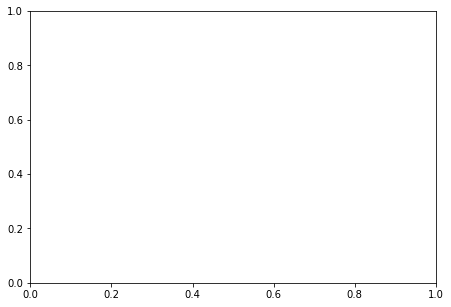

In [20]:
fig=plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
y1=df['val_acc'].round(decimals = 2)
#print(y1)
y2=df['train_acc'].round(decimals = 2)
ci = 0.6* np.std(y1) / np.mean(y1)
plt.plot(x,y1,label='Testing Accuracy',color = 'b',marker='*', markersize=7)
plt.fill_between(x, (y1-ci), (y1+ci), color='blue', alpha=0.1)
plt.plot(x,y2,label='Training Accuracy',color = 'darkred', marker='.', markersize=10)
plt.fill_between(x, (y2-ci), (y2+ci), color='red', alpha=0.1)
plt.title('(A)',fontweight='bold', fontsize=20)
plt.legend(title = 'Accuracy', loc = 4, fontsize = 10)
plt.xlim([1,30])
plt.ylim([0.5,1.02])
plt.xlabel('Epoch',fontweight='bold',fontsize= 20)
plt.ylabel('Accuracy',fontweight='bold',fontsize= 20)
plt.yticks([0.5,.55,.6,.65,.7,.75,.8,.85,.9,.95,1],fontweight='bold', fontsize=15)
plt.xticks(fontweight='bold', fontsize=15)

plt.subplot(1,2,2)


y1=df1['val_loss'].round(decimals = 2)

i=0
#while i<5:
    #y1[i]=y1[i]+1
    #i+=1
#y1[5]=1.5
#y1[39]=.92
#print(y1)
y2=df['train_loss'].round(decimals = 2)
ci = 0.2* np.std(y1) / np.mean(y1)
plt.plot(x,y1,label='Testing Loss',color = 'b',marker='*', markersize=7)
plt.fill_between(x, (y1-ci), (y1+ci), color='blue', alpha=0.1)
plt.plot(x,y2,label='Training Loss',color = 'darkred', marker='.', markersize=10)
plt.fill_between(x, (y2-ci), (y2+ci), color='red', alpha=0.1)
plt.title('(B)',fontweight='bold', fontsize=20)
plt.legend(title = 'Loss', loc = 0, fontsize=10)
plt.xlim([1,30])
plt.ylim([0,2])
plt.xlabel('Epoch',fontweight='bold', fontsize=20)
plt.ylabel('Loss',fontweight='bold', fontsize=20)
plt.yticks(fontweight='bold', fontsize=15)
plt.xticks(fontweight='bold', fontsize=15)
plt.savefig('', dpi=300, transparent=True,bbox_inches='tight')
plt.show()

In [108]:
thisdict = {
  "brand": "Ford",
  "model": "Mustang",
  "year": 1964
}

In [1]:

l1=[87, 84.3, 80.23]

l2=['BERT', 'LSTM with Attention', 'LSTM', 'Simple RNN']

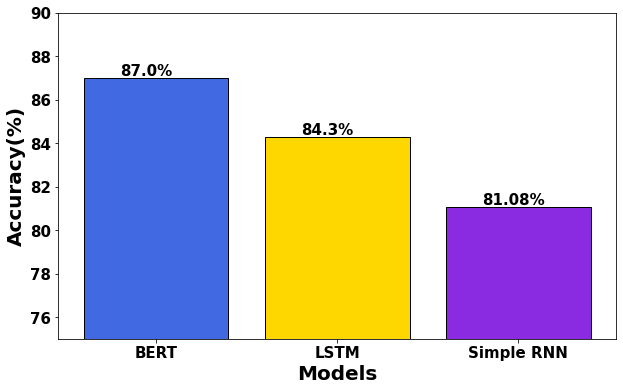

In [2]:
from matplotlib import pyplot as plt
fig = plt.figure(figsize =(10, 6))
#rects = ax.patches
 
# Horizontal Bar Plot
rects=plt.bar(l2, l1, color=['royalblue','gold','blueviolet','lightseagreen'],edgecolor='black',align = 'center')
plt.ylim([75,90])
plt.xlabel('Models',fontweight='bold', fontsize=20)
plt.ylabel('Accuracy(%)',fontweight='bold', fontsize=20)
plt.yticks(fontweight='bold', fontsize=15)
plt.xticks(fontweight='bold', fontsize=15)
#plt.legend( ncol=4, fancybox=False, shadow=True)
#Show Plot

for bar in rects:
    yval = bar.get_height()
    plt.text(bar.get_x()+.2, yval + .1, str(yval)+'%',fontweight='bold', fontsize=15)
plt.savefig('CompClass.pdf', dpi=300, transparent=True,bbox_inches='tight')
plt.show()

In [ ]:
color='royalblue',
Shoaib
color='gold',
Shoaib
color='blueviolet',
Shoaib
color='lightseagreen'

In [2]:
model_name = ["SVM", "Decision tree", "Random forest", "Xgboost", "Naive Bayes", "K-Nearest Neighbors", "GradientBoostingClassifier", "LogisticRegression"]

model_accuracy_without_fearture_selection = [89.90825688073394, 97.24770642201835, 96.3302752293590, 94.4954128440367, 94.4954128440367, 88.9908256880734, 95.41284403669725, 95.41284403669725]




#With feature selection:

model_name = ["SVM", "Decision tree", "Random forest", "Xgboost", "Naive Bayes", "K-Nearest Neighbors", "GradientBoostingClassifier", "LogisticRegression"]

model_accuracy_with_fearture_selection = [92.66055045871559, 97.98256880733946, 96.9302752293578, 94.4954128440367, 94.4954128440367, 96.3302752293578, 96.3302752293578, 95.4954128440367]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
#figure(num=None, figsize=(20, 16), dpi=1000, facecolor='w', edgecolor='k')
# data to plot

plt.rcParams["figure.figsize"] = (16,10)
#plt.rcParams["figure.dpi"] = 1000

# Group Number Need to defined first 

n_groups = 2

SVM =(89.91, 92.66)

Decision_tree = (97.25, 97.98)

Random_forest = (96.33, 96.93)

Xgboost = (94.5, 94.5)

Naive_Bayes = (94.5, 94.5)

K_Nearest_Neighbors = (88.99, 96.33)

GradientBoostingClassifier = (95.41, 96.33)

LogisticRegression = (95.41, 95.5)




# create plot
fig, ax = plt.subplots()
index = np.arange(n_groups)
bar_width = 0.10
opacity = 1

rects1 = plt.bar(index, SVM, bar_width,
alpha=opacity,
color='royalblue',
label='SVM',
align = 'center')

rects2 = plt.bar(index + bar_width, Decision_tree, bar_width,
alpha=opacity,
color='gold',
label='Decision Tree',
align = 'center')

rects3 = plt.bar(index + bar_width*2, LogisticRegression, bar_width,
alpha=opacity,
color='blueviolet',
label='logistic regression',
align = 'center')

rects4 = plt.bar(index + bar_width*3, Naive_Bayes, bar_width,
alpha=opacity,
color='lightseagreen',
label='Naive Bayes',
align = 'center')

rects5 = plt.bar(index + bar_width*4, Random_forest, bar_width,
alpha=opacity,
color='green',
label='Random Forest',
align = 'center')

rects6 = plt.bar(index + bar_width*5, Xgboost, bar_width,
alpha=opacity,
color='blue',
label='XGBoost',
align = 'center')

rects7 = plt.bar(index + bar_width*6, K_Nearest_Neighbors, bar_width,
alpha=opacity,
color='red',
label='K Nearest Neighbors',
align = 'center')

rects8 = plt.bar(index + bar_width*7, GradientBoostingClassifier, bar_width,
alpha=opacity,
color='pink',
label='Gradient Boosting Classifier',
align = 'center')




# Fixed Y axis interval
#y = [.1,.2,.3,.4,.5]
#plt.yticks(np.arange(min(y), max(y)+.1, .1))
#plt.yticks(np.arange(60, 150, 10))
plt.ylim(65,103)

plt.xlabel('Metrics', fontweight='bold', fontsize=20)
plt.ylabel('Score (%)', fontweight='bold', fontsize=20)
#plt.title('Classification Summary', fontweight='bold', fontsize=18)
#plt.xticks(index + bar_width, ('0.25', '0.50'))
#plt.xticks(index + bar_width, ('$I_1$', '$I_2$', '$I_3$', '$I_4$'))
plt.xticks(index + bar_width*3, ('Without Feature Selection', 'With Feature Selection'), fontweight='bold', fontsize=15)
plt.yticks(fontweight='bold', fontsize=15)

#plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
 #         fancybox=True, ncol=5)
plt.legend(loc='best', 
          ncol=4, fancybox=True, shadow=True)

def autolabel(rects):
    """Attach a text label above each bar in rects, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')


autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)
autolabel(rects5)
autolabel(rects6)
autolabel(rects7)
autolabel(rects8)

#autolabel(rects4)

#plt.legend()
plt.tight_layout()
#plt.savefig('ClassificationComparision.pdf', dpi=3000,transparent=True,bbox_inches='tight')
plt.savefig('ClassificationComparision.png', dpi=3000, transparent=True,bbox_inches='tight')

plt.show()

In [1]:
conf=[[ 84 ,  8 ,  0 ,  1 ,  2 ,  0 ,  0 ,  0 ,  1 ,  0],
 [  3 ,443 ,  8 ,  8 ,  2 ,  3,   8 , 10 , 10 ,  2],
 [  0 , 15 , 55 ,  0 ,  1 ,  0,   0 ,  2 ,  0 ,  1],
 [  3 ,  3 ,  0 , 93 ,  0 ,  2,   2 ,  0 ,  2 ,  1],
 [  1 ,  1 ,  0 ,  1 ,172 ,  0,   0 ,  0 ,  0 ,  0],
 [  0 ,  5 ,  0 ,  5 ,  0 , 65,   0 ,  1 ,  0 ,  0],
 [  0 , 23 ,  0 ,  4 ,  0 ,  0, 136 ,  1 ,  1 ,  1],
 [  1 ,  6 ,  4 ,  2 ,  0 ,  2,   2 , 68 ,  3 ,  2],
 [  0 ,  6 ,  2 ,  1 ,  0 ,  1,   1 ,  8 ,170 ,  1],
 [  0 , 14 ,  4 ,  3 ,  0 ,  0,   1 ,  0 ,  8 , 94]]

In [2]:
labels=['Sports and\n Fitness',
        'Health',
        'Relationships',
        'Home and\n Garden',
        'Pets and\n Animals',
        'Food and \n Entertaining',
        'Personal Care\n and Style',
        'Family Life', 
        'Finance and \n Business',
        'Education and \n Communications']

In [3]:
print(labels)

['Sports and\n Fitness', 'Health', 'Relationships', 'Home and\n Garden', 'Pets and\n Animals', 'Food and \n Entertaining', 'Personal Care\n and Style', 'Family Life', 'Finance and \n Business', 'Education and \n Communications']


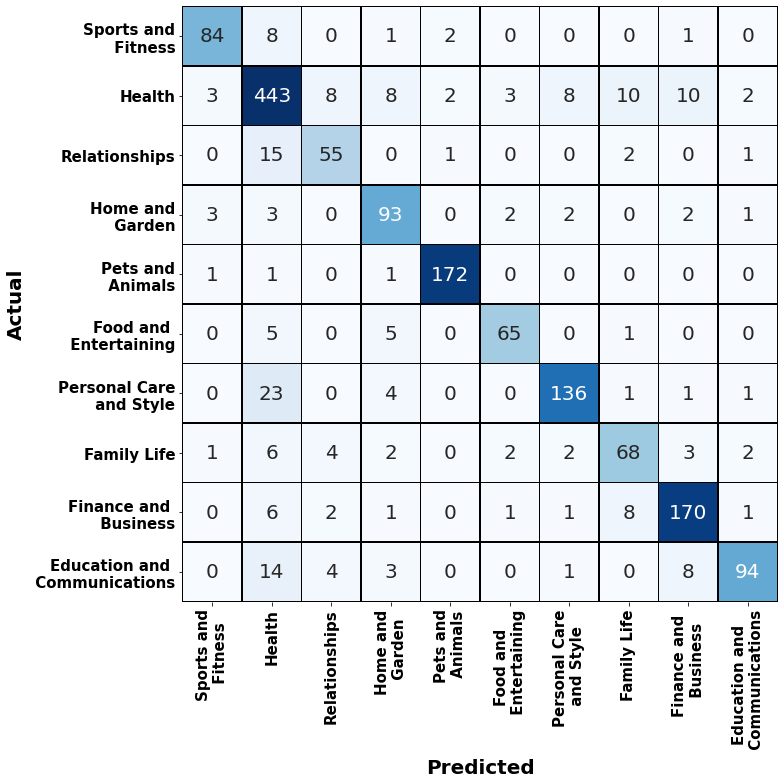

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
fig=plt.figure(figsize=(14,11))
sns.heatmap(conf,cmap="Blues", linecolor='black',annot=True,square=True,
            fmt='d',linewidths=.2,vmax=180,cbar=False,xticklabels=labels, yticklabels=labels,annot_kws={"size": 20})
plt.xticks(fontweight='bold', fontsize=15)
plt.yticks(fontweight='bold', fontsize=15)
plt.xlabel('Predicted',fontweight='bold', fontsize=20)
plt.ylabel('Actual',fontweight='bold', fontsize=20)
plt.tight_layout()
plt.savefig('InsHeatmap.pdf', dpi=3000)


plt.show()

In [29]:
j=0
Recall=[]
for i in conf:
    Recall.append(int(i[j])/sum(i))
    print(i[j])
    j+=1
print(Recall)
Recall=[round(num,2) for num in Recall]
print(Recall)
    

84
443
55
93
172
65
136
68
170
94
[0.875, 0.8913480885311871, 0.7432432432432432, 0.8773584905660378, 0.9828571428571429, 0.8552631578947368, 0.8192771084337349, 0.7555555555555555, 0.8947368421052632, 0.7580645161290323]
[0.88, 0.89, 0.74, 0.88, 0.98, 0.86, 0.82, 0.76, 0.89, 0.76]


In [30]:
j=0
Prec=[]
for i in conf:
    sum_col=0
    for k in conf:
        sum_col+=k[j]
    Prec.append(int(i[j])/sum_col)
    print(i[j])
    j+=1
print(Prec)
Prec=[round(num,2) for num in Prec]
print(Prec)

84
443
55
93
172
65
136
68
170
94
[0.9130434782608695, 0.8454198473282443, 0.7534246575342466, 0.788135593220339, 0.9717514124293786, 0.8904109589041096, 0.9066666666666666, 0.7555555555555555, 0.8717948717948718, 0.9215686274509803]
[0.91, 0.85, 0.75, 0.79, 0.97, 0.89, 0.91, 0.76, 0.87, 0.92]


In [31]:
i=0
f1_scr=[]
while i<len(labels):
    s = 2*Recall[i]*Prec[i]
    m = Recall[i]+Prec[i]
    print(i,'  ',s,'  ',m)
    f1_scr.append(s/m)
    i+=1
print(f1_scr)
f1_scr=[round(num,2)*100 for num in f1_scr]
print(f1_scr)   

0    1.6016000000000001    1.79
1    1.513    1.74
2    1.1099999999999999    1.49
3    1.3904    1.67
4    1.9012    1.95
5    1.5308    1.75
6    1.4924    1.73
7    1.1552    1.52
8    1.5486    1.76
9    1.3984    1.6800000000000002
[0.8947486033519554, 0.8695402298850574, 0.7449664429530201, 0.8325748502994013, 0.974974358974359, 0.8747428571428572, 0.8626589595375722, 0.76, 0.8798863636363636, 0.8323809523809523]
[89.0, 87.0, 74.0, 83.0, 97.0, 87.0, 86.0, 76.0, 88.0, 83.0]


In [5]:
df11=pd.read_csv('dataset.csv',usecols=[1,2])

In [6]:
df11.head()

,category,text
0,Education and Communications,Start your Works Cited entry with the author's...
1,Education and Communications,List the author's name and date of publication...
2,Sports and Fitness,Know the main point of the game. The goal of A...
3,Sports and Fitness,Quarterback. The offense's backbone. The quart...
4,Sports and Fitness,Throw a circle changeup. The technique for thr...


In [8]:
print(df11['text'][0])

Start your Works Cited entry with the author's name. List the author's last name first, followed by a comma and a space. Type the author's first name and middle name or initial, if provided. Place a period at the end of the author's name.  Example: Buchman, Dana. If there are 2 authors, separate their names with a comma, typing the word "and" before the last author's name. Only invert the first author's name. For example: Martin, Johnathan A., and Christopher Jackson. For 3 or more authors, list the first author's name, followed by a comma and the abbreviation "et. al." For example: Fontela, Pablo, et. al.    Provide the title of the article in double quotation marks. Type the title of the article in title case, capitalizing the first word along with all nouns, pronouns, verbs, adverbs, and words with more than 4 letters. Place a period at the end of the title, inside the closing quotation marks.  Example: Buchman, Dana. "A Special Education." If the article has a subtitle, type a colo

AttributeError: 'AxesSubplot' object has no attribute 'bar_label'

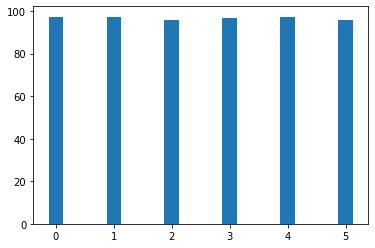

In [2]:
import numpy as np

models = ("XLNet", "BERT", "ELECTRA","RoBERTa","DistilBert", "LSTM",)
penguin_means = {
    'Accuracy': (97.31, 97.17, 95.98, 96.90, 97.02, 95.80),
    'Macro F1 Score': (94.00, 90.45, 87.56, 89.01, 90.20, 85.09),
}

x = np.arange(len(models))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots()

for attribute, measurement in penguin_means.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Length (mm)')
ax.set_title('Penguin attributes by species')
ax.set_xticks(x + width, models)
ax.legend(loc='upper right')
ax.set_ylim(70, 110)

plt.show()